In [1]:
import os
from astropy.cosmology import FlatLambdaCDM
from astropy.units import Quantity
from astropy.table import Table, vstack
import slsim.Pipelines as pipelines
import numpy as np
from astropy import units as u
from slsim.Sources.SourceCatalogues.QuasarCatalog.quasar_pop import QuasarRate

import warnings
warnings.filterwarnings("ignore")

# Ensure the catalogs directory exists
output_dir = "../catalogs"
os.makedirs(output_dir, exist_ok=True)

In [2]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

## SkyPy Galaxies Catalog

In [4]:
# Generate and Save SkyPy Catalogs
sky_area_galaxy = Quantity(10, "deg2")

print(f"Generating SkyPy catalogs over {sky_area_galaxy}...")
galaxy_pipeline = pipelines.SkyPyPipeline(sky_area=sky_area_galaxy, cosmo=cosmo)

red_galaxy_catalog = galaxy_pipeline.red_galaxies
blue_galaxy_catalog = galaxy_pipeline.blue_galaxies
all_galaxy_catalog = vstack([red_galaxy_catalog, blue_galaxy_catalog])

print(f"Generated {len(red_galaxy_catalog)} red galaxies.")
print(f"Generated {len(blue_galaxy_catalog)} blue galaxies.")
print("Saving catalogs to FITS format...")

# Save as FITS (ideal for Astropy Tables with units/metadata)
red_galaxy_catalog.write(os.path.join(output_dir, f"skypy_red_galaxies_{sky_area_galaxy.value}deg2.fits"), format='fits', overwrite=True)
blue_galaxy_catalog.write(os.path.join(output_dir, f"skypy_blue_galaxies_{sky_area_galaxy.value}deg2.fits"), format='fits', overwrite=True)
all_galaxy_catalog.write(os.path.join(output_dir, f"skypy_all_galaxies_{sky_area_galaxy.value}deg2.fits"), format='fits', overwrite=True)

print("Catalogs saved successfully!")

Generating SkyPy catalogs over 10.0 deg2...
Generated 847271 red galaxies.
Generated 13132086 blue galaxies.
Saving catalogs to FITS format...
Catalogs saved successfully!


In [4]:
# Generate and Save SkyPy Catalogs
sky_area_galaxy = Quantity(2, "deg2")

print(f"Generating SkyPy catalogs over {sky_area_galaxy}...")
galaxy_pipeline = pipelines.SkyPyPipeline(sky_area=sky_area_galaxy, cosmo=cosmo)

red_galaxy_catalog = galaxy_pipeline.red_galaxies
blue_galaxy_catalog = galaxy_pipeline.blue_galaxies
all_galaxy_catalog = vstack([red_galaxy_catalog, blue_galaxy_catalog])

print(f"Generated {len(red_galaxy_catalog)} red galaxies.")
print(f"Generated {len(blue_galaxy_catalog)} blue galaxies.")
print("Saving catalogs to FITS format...")

# Save as FITS (ideal for Astropy Tables with units/metadata)
red_galaxy_catalog.write(os.path.join(output_dir, f"skypy_red_galaxies_{sky_area_galaxy.value}deg2.fits"), format='fits', overwrite=True)
blue_galaxy_catalog.write(os.path.join(output_dir, f"skypy_blue_galaxies_{sky_area_galaxy.value}deg2.fits"), format='fits', overwrite=True)
all_galaxy_catalog.write(os.path.join(output_dir, f"skypy_all_galaxies_{sky_area_galaxy.value}deg2.fits"), format='fits', overwrite=True)

print("Catalogs saved successfully!")

Generating SkyPy catalogs over 2.0 deg2...
Generated 168906 red galaxies.
Generated 2624684 blue galaxies.
Saving catalogs to FITS format...
Catalogs saved successfully!


In [4]:
# Generate and Save SkyPy Catalogs
sky_area_galaxy = Quantity(1, "deg2")

print(f"Generating SkyPy catalogs over {sky_area_galaxy}...")
galaxy_pipeline = pipelines.SkyPyPipeline(sky_area=sky_area_galaxy, cosmo=cosmo)

red_galaxy_catalog = galaxy_pipeline.red_galaxies
blue_galaxy_catalog = galaxy_pipeline.blue_galaxies
all_galaxy_catalog = vstack([red_galaxy_catalog, blue_galaxy_catalog])

print(f"Generated {len(red_galaxy_catalog)} red galaxies.")
print(f"Generated {len(blue_galaxy_catalog)} blue galaxies.")
print("Saving catalogs to FITS format...")

# Save as FITS (ideal for Astropy Tables with units/metadata)
red_galaxy_catalog.write(os.path.join(output_dir, f"skypy_red_galaxies_{sky_area_galaxy.value}deg2.fits"), format='fits', overwrite=True)
blue_galaxy_catalog.write(os.path.join(output_dir, f"skypy_blue_galaxies_{sky_area_galaxy.value}deg2.fits"), format='fits', overwrite=True)
all_galaxy_catalog.write(os.path.join(output_dir, f"skypy_all_galaxies_{sky_area_galaxy.value}deg2.fits"), format='fits', overwrite=True)

print("Catalogs saved successfully!")

Generating SkyPy catalogs over 1.0 deg2...
Generated 84307 red galaxies.
Generated 1313778 blue galaxies.
Saving catalogs to FITS format...
Catalogs saved successfully!


## Quasar+Host Catalog from AGILE

In [3]:
path_to_agile_catalog = os.path.join(output_dir, "agile_catalog_unobscured_agn.fits")
agile_catalog = Table.read(path_to_agile_catalog);

# choose unobscured quasars
agile_catalog = agile_catalog[
    (agile_catalog['is_agn'] == 1) & (agile_catalog['is_optical_type2'] == 0)
    ]

agile_catalog

ID,RA,DEC,Z,M,SFR,is_agn_ctn,is_agn_ctk,is_agn,is_optical_type2,DISK_RADIUS,BULGE_RADIUS,DISK_RATIO,DISK_ANGLE,BULGE_RATIO,BULGE_ANGLE,MBH,log_L_bol,log_lambda_Edd,lsst-u_total,lsst-u_disk,lsst-u_bulge,lsst-u_point,magabs_lsst-u_point,lsst-g_total,lsst-g_disk,lsst-g_bulge,lsst-g_point,magabs_lsst-g_point,lsst-r_total,lsst-r_disk,lsst-r_bulge,lsst-r_point,magabs_lsst-r_point,lsst-i_total,lsst-i_disk,lsst-i_bulge,lsst-i_point,magabs_lsst-i_point,lsst-z_total,lsst-z_disk,lsst-z_bulge,lsst-z_point,magabs_lsst-z_point,lsst-y_total,lsst-y_disk,lsst-y_bulge,lsst-y_point,magabs_lsst-y_point
int64,float64,float64,float64,float64,float64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
669,149.77913078298394,4.588169416887185,1.0538777112960815,10.622429847717285,5.679090976715088,1,0,1,0,0.30594924092292786,0.17215263843536377,0.5439417958259583,-75.16017150878906,0.30675506591796875,-75.16017150878906,7.3377487740959335,45.9335514819009,0.4954321626874023,27.10140821474662,0.6583508849143982,0.01153009943664074,26.43152723039558,-23.726187644958756,34.01731327747803,0.8955351710319519,0.024406446143984795,33.097371660302095,-23.86571505552565,47.12243259479132,1.2334064245224,0.0993543341755867,45.78967183609333,-24.227622652885717,48.49739670089298,1.8351103067398071,0.2808324098587036,46.38145398429447,-23.984892412428913,51.660474469307324,2.9881632328033447,0.7075280547142029,47.96478318178978,-23.98375864620279,60.51153897089612,3.7269136905670166,1.1019738912582397,55.68265138907086,-24.115718035788625
935,149.41127816270898,1.1298218476350887,2.371891975402832,10.762886047363281,92.3348617553711,1,0,1,0,0.5741918087005615,0.20241805911064148,0.7736381888389587,-78.25929260253906,0.7996389269828796,-78.25929260253906,6.980110808423868,44.57591841515982,-0.5045629383816124,0.09191155460660053,0.00698503665626049,7.932524749776348e-05,0.08484719270284227,-20.308787128508783,0.2379438357661025,0.055222850292921066,0.00011812220327556133,0.18260286326990588,-20.45578313714314,0.3468232704545132,0.12293946743011475,0.0005725963274016976,0.22331120669699678,-20.85164354709516,0.4558029099828828,0.1819591373205185,0.0034018075093626976,0.2704419651530016,-20.568635719887972,0.6055335255191308,0.2468065768480301,0.008041789755225182,0.35068515891587554,-20.55311362419225,0.8033369166839629,0.337641179561615,0.023067189380526543,0.44262854774182137,-20.68599770928131
1598,149.3598117925901,2.309396695405802,0.8843787908554077,8.576791763305664,0.8941977024078369,1,0,1,0,0.1143917366862297,0.021279077976942062,0.5192568898200989,35.58650588989258,0.687299907207489,35.58650588989258,4.440523067121883,41.613713431395745,-0.9271801808437017,0.27413061329446303,0.2710879147052765,0.00014216153067536652,0.002900537058511198,-13.289379736907762,0.29106580700872225,0.2869323194026947,0.0002042652922682464,0.003929222313759324,-13.299737722396344,0.3246868688044456,0.3197045922279358,0.0005479180254042149,0.00443435855110556,-13.680482364521582,0.5335056085503113,0.5278761386871338,0.001505007385276258,0.004124462477901246,-13.286121606892024,0.5966481430387879,0.5893703699111938,0.0027718644123524427,0.004505908715241574,-13.222671587138386,0.6758034218431754,0.6674693822860718,0.003595835529267788,0.004738204027835828,-13.350995273720068
1980,149.9645023565261,1.5356801933088104,2.5721309185028076,10.595592498779297,109.9815673828125,1,0,1,0,0.46181315183639526,0.29969537258148193,0.3732644021511078,-43.01392364501953,0.3363291025161743,-43.01392364501953,7.217427801967883,45.63347294838,0.3156746012945568,1.644045582876367,0.30134740471839905,0.024467376992106438,1.3182308011658614,-23.10603958115812,3.9979313989234817,1.3841577768325806,0.047408588230609894,2.5

In [4]:
data = [
    23.9 - 2.5*np.log10(agile_catalog['lsst-u_point']), # lsst point source flux in microJanskys converted to mag using 23.9 - 2.5 log10(flux_microJy)
    23.9 - 2.5*np.log10(agile_catalog['lsst-g_point']),
    23.9 - 2.5*np.log10(agile_catalog['lsst-r_point']),
    23.9 - 2.5*np.log10(agile_catalog['lsst-i_point']),
    23.9 - 2.5*np.log10(agile_catalog['lsst-z_point']),
    23.9 - 2.5*np.log10(agile_catalog['lsst-y_point']),
    agile_catalog['Z'],     # redshift
    # np.random.uniform(-1, 1, size=len(agile_catalog)), # random x position in the image
    # np.random.uniform(-1, 1, size=len(agile_catalog)), # random y position in the image
    23.9 - 2.5 * np.log10(agile_catalog['lsst-u_disk']+agile_catalog['lsst-u_bulge']), # convert microJanskys to total mag of extended source
    23.9 - 2.5 * np.log10(agile_catalog['lsst-g_disk']+agile_catalog['lsst-g_bulge']),
    23.9 - 2.5 * np.log10(agile_catalog['lsst-r_disk']+agile_catalog['lsst-r_bulge']),
    23.9 - 2.5 * np.log10(agile_catalog['lsst-i_disk']+agile_catalog['lsst-i_bulge']),
    23.9 - 2.5 * np.log10(agile_catalog['lsst-z_disk']+agile_catalog['lsst-z_bulge']),
    23.9 - 2.5 * np.log10(agile_catalog['lsst-y_disk']+agile_catalog['lsst-y_bulge']),
    agile_catalog['lsst-i_disk'] / (agile_catalog['lsst-i_disk'] + agile_catalog['lsst-i_bulge']), # calculate disk fraction of emission compared to total extended emission 
    agile_catalog['lsst-i_bulge'] / (agile_catalog['lsst-i_disk'] + agile_catalog['lsst-i_bulge']),# assuming that the i-band is representative of each band
    agile_catalog['DISK_RADIUS'], # disk radius in arcsec
    agile_catalog['BULGE_RADIUS'], # bulge radius in arcsec
    (1 - agile_catalog['DISK_RATIO'])/(1 + agile_catalog['DISK_RATIO']) * np.cos(2 * agile_catalog['DISK_ANGLE'] * np.pi / 180),
    (1 - agile_catalog['DISK_RATIO'])/(1 + agile_catalog['DISK_RATIO']) * np.sin(2 * agile_catalog['DISK_ANGLE'] * np.pi / 180),
    (1 - agile_catalog['BULGE_RATIO'])/(1 + agile_catalog['BULGE_RATIO']) * np.cos(2 * agile_catalog['BULGE_ANGLE'] * np.pi / 180),
    (1 - agile_catalog['BULGE_RATIO'])/(1 + agile_catalog['BULGE_RATIO']) * np.sin(2 * agile_catalog['BULGE_ANGLE'] * np.pi / 180),
    np.ones(np.shape(agile_catalog['magabs_lsst-u_point'])),
    2 * np.ones(np.shape(agile_catalog['magabs_lsst-u_point'])),
    agile_catalog['DISK_RADIUS'] * (u.arcsec.to(u.rad)) * cosmo.angular_diameter_distance(agile_catalog['Z'].value).to(u.kpc).value, # physical size in kpc, assuming disk radius is in arcsec
    agile_catalog['MBH'], # black hole mass in solar masses
    agile_catalog['log_L_bol'], # log of bolometric luminosity
    10**(agile_catalog['log_lambda_Edd']), # Eddington ratio
]
    
col_names = [
    'ps_mag_u', #point source mags
    'ps_mag_g',
    'ps_mag_r',
    'ps_mag_i',
    'ps_mag_z',
    'ps_mag_y',
    'z',        #redshift
    # 'center_x', #center of object
    # 'center_y',
    'mag_u',    #extended source TOTAL mags 
    'mag_g',
    'mag_r',
    'mag_i',
    'mag_z',
    'mag_y',
    'w0',       #relative weights of each sersic profile for disk / bulge
    'w1',
    'angular_size_0', #If double sersic profile, defines R_sersic for component 0
    'angular_size_1', # same for component 1
    'e0_1',       #ellipticity1, defined as (1-q)/(1+q) * cos(2 phi), with q = minor-to-major axis ratio
    'e0_2',       #ellipticity2, defined as (1-q)/(1+q) * sin(2 phi)
    'e1_1',
    'e1_2',
    'n_sersic_0', #sersic index of component 0 of extended source
    'n_sersic_1', #sersic index of component 1 of extended source    
    'physical_size', #in kpc, assuming disk radius is in arcsec
    'black_hole_mass_exponent', # in solar masses
    'log_L_bol', # log of bolometric luminosity
    'eddington_ratio' # Eddington ratio
]


slsim_catalog_table = Table(data, names=col_names, ) # make an astropy table to inject into SLSim

slsim_catalog_table = slsim_catalog_table[(~np.isinf(slsim_catalog_table['ps_mag_g'])) & np.isfinite(slsim_catalog_table['z'])]

# fix units for the table
units_slsim_catalog_table = {
    'ps_mag_u': u.mag,
    'ps_mag_g': u.mag,
    'ps_mag_r': u.mag,
    'ps_mag_i': u.mag,
    'ps_mag_z': u.mag,
    'ps_mag_y': u.mag,
    'z': u.dimensionless_unscaled,
    'center_x': u.arcsec,
    'center_y': u.arcsec,
    'mag_u': u.mag,
    'mag_g': u.mag,
    'mag_r': u.mag,
    'mag_i': u.mag,
    'mag_z': u.mag,
    'mag_y': u.mag,
    'w0': u.dimensionless_unscaled,
    'w1': u.dimensionless_unscaled,
    'angular_size_0': u.arcsec,
    'angular_size_1': u.arcsec,
    'e0_1': u.dimensionless_unscaled,
    'e0_2': u.dimensionless_unscaled,
    'e1_1': u.dimensionless_unscaled,
    'e1_2': u.dimensionless_unscaled,
    'n_sersic_0': u.dimensionless_unscaled,
    'n_sersic_1': u.dimensionless_unscaled,
    'physical_size': u.kpc,
    'black_hole_mass_exponent': u.dimensionless_unscaled,
    'log_L_bol': u.dimensionless_unscaled,
    'eddington_ratio': u.dimensionless_unscaled
}

for col in slsim_catalog_table.colnames:
    slsim_catalog_table[col].unit = units_slsim_catalog_table.get(col, u.dimensionless_unscaled)


slsim_catalog_table = slsim_catalog_table[slsim_catalog_table['w0'] + slsim_catalog_table['w1'] == 1]

slsim_catalog_table['ps_mag_i', 'mag_i']

ps_mag_i,mag_i
mag,mag
float64,float64
19.734139102620553,23.086240234552807
25.319814792363353,25.729954413769224
29.861581607538163,24.5905788254301
22.544284505393005,22.91085284348712
26.54655536154023,24.248337805599416
21.046148362789385,21.957170932344525
20.734506509449425,22.374740033391102
20.448699210024742,22.808842313385725


In [5]:
# save the SLSim catalog as a FITS file
slsim_catalog_table.write(os.path.join(output_dir, "agile_qsos.fits"), format='fits', overwrite=True)

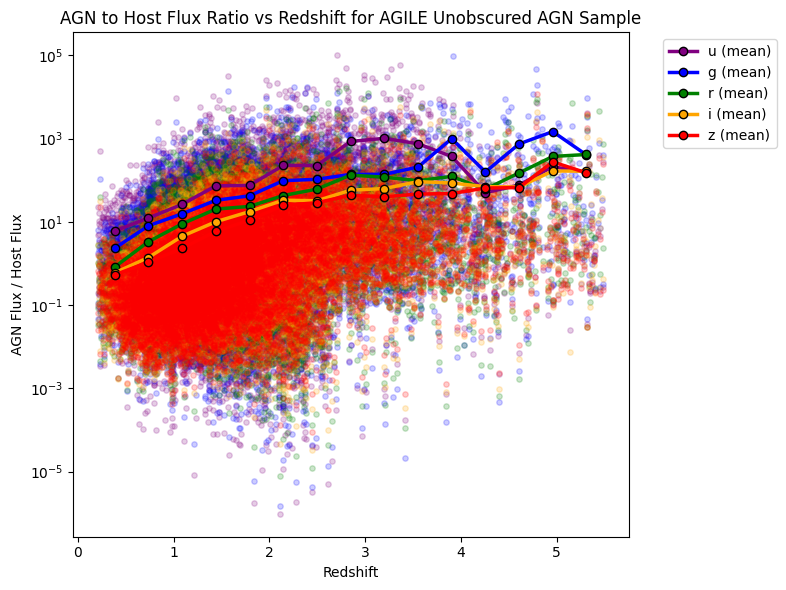

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

fig, ax = plt.subplots(figsize=(8, 6))

# Define colors for consistency between scatter points and their mean lines
band_colors = {'u': 'purple', 'g': 'blue', 'r': 'green', 'i': 'orange', 'z': 'red'}

# Define the number of redshift bins
num_bins = 15 

for band in ['u', 'g', 'r', 'i', 'z']:
    # Extract data
    redshifts = agile_catalog['Z']
    host_flux = agile_catalog[f'lsst-{band}_disk'] + agile_catalog[f'lsst-{band}_bulge']
    agn_flux = agile_catalog[f'lsst-{band}_point']
    
    # Calculate the y-axis ratio
    flux_ratio = agn_flux / host_flux

    # 1. Plot the scatter points
    ax.scatter(redshifts, flux_ratio, alpha=0.2, 
               color=band_colors[band], s=15)
    
    # 2. Calculate the binned mean of the flux ratio across redshift bins
    bin_means, bin_edges, _ = binned_statistic(redshifts, flux_ratio, statistic='mean', bins=num_bins)
    
    # 3. Calculate the center of each bin for the x-coordinates
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    # 4. Plot the binned mean overlaid on top
    ax.plot(bin_centers, bin_means, marker='o', linestyle='-', linewidth=2.5, 
            color=band_colors[band], markeredgecolor='black', label=f'{band} (mean)')

# Set scales and labels
ax.set_yscale('log')
ax.set_xlabel('Redshift')
ax.set_ylabel('AGN Flux / Host Flux')

# Keep the legend organized outside the plot limits
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('AGN to Host Flux Ratio vs Redshift for AGILE Unobscured AGN Sample')
plt.tight_layout()
plt.show()

## Quasar+Host Catalog from SLSim

In [5]:
sky_area_quasar = Quantity(10, "deg2")  # smaller area for quasars to speed up generation

# generate galaxy population using skypy pipeline.
galaxy_simulation_pipeline = pipelines.SkyPyPipeline(
    sky_area=sky_area_quasar,
    cosmo=cosmo,
)


# define host galaxy candidates for the quasars
host_galaxy_candidates = vstack(
    [galaxy_simulation_pipeline.red_galaxies, galaxy_simulation_pipeline.blue_galaxies],
    join_type="exact",
)

print(f"Generated {len(host_galaxy_candidates)} host galaxy candidates for quasars.")

print("Generating quasar sample using SLSim's QuasarRate class...")
# Initiate QuasarRate class to generate quasar sample.
quasar_class = QuasarRate(
    cosmo=cosmo,
    sky_area=sky_area_quasar,
    noise=True,
    redshifts=np.linspace(0.001, 5.01, 100),  # these redshifts are provided
    # to match general slsim redshift range in skypy pipeline.
    host_galaxy_candidate=host_galaxy_candidates,
    # To have realistic colors and magnitudes in Roman and LSST bands
    use_qsogen_sed=True,
    qsogen_bands=[
        "g",
        "r",
        "i",
        "z",
        "y",  # LSST bands
    ],
    use_sed_interpolator=True,
)
quasar_source = quasar_class.quasar_sample(m_min=15, m_max=30, host_galaxy=True)

Generated 13972697 host galaxy candidates for quasars.
Generating quasar sample using SLSim's QuasarRate class...


Matching quasars with host galaxies: 100%|██████████| 105726/105726 [00:37<00:00, 2824.13it/s]


In [6]:
# save the quasar catalog as a FITS file
quasar_source.write(os.path.join(output_dir, "slsim_qsos.fits"), format='fits', overwrite=True)